# Analysis of Synthetic Data Generation Results
This notebook merges all results from the `Results` directory and generates plots to answer the research questions.

In [7]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Directory to save figures
os.makedirs('Output_Figures', exist_ok=True)

## 1. Merge all results into a single file

In [8]:
result_dir = '../Results'
all_csv_files = []

for root, dirs, files in os.walk(result_dir):
    if 'Old result' in root:
        continue
    for file in files:
        if file.endswith('_results.csv'):
            all_csv_files.append(os.path.join(root, file))

print(f"Found {len(all_csv_files)} CSV files.")

df_list = []
for file in all_csv_files:
    df = pd.read_csv(file)
    df_list.append(df)

df_all = pd.concat(df_list, ignore_index=True)
df_all.to_csv('Merged_Results.csv', index=False)

if 'SeedFoldSelection' in df_all.columns:
    print("Aggregating across SeedFoldSelection for visualizations...")
    groupby_cols = [c for c in df_all.columns if c not in ['SeedFoldSelection', 'Accuracy', 'F1_Score', 'ExecutionTime_Sec', 'Hyperparameters']]
    df_all['Hyperparameters'] = df_all['Hyperparameters'].astype(str)
    df_all = df_all.groupby(groupby_cols).agg({'Accuracy': 'mean', 'F1_Score': 'mean', 'ExecutionTime_Sec': 'mean', 'Hyperparameters': 'first'}).reset_index()

print(f"Dataset shape for visualization: {df_all.shape}")
display(df_all.head())


Found 125 CSV files.
Aggregating across SeedFoldSelection for visualizations...
Dataset shape for visualization: (18150, 10)


,Dataset,Fold,SeedsPerLabel,ScaleFactor,Model,Method,Accuracy,F1_Score,ExecutionTime_Sec,Hyperparameters
0,Brewed_vinegar,1,1,1,KNN,Baseline,0.984933,0.984969,0.007230,"{'algorithm': 'auto', 'leaf_size': 30, 'metric..."
1,Brewed_vinegar,1,1,1,KNN,Tuned_Baseline,0.984933,0.984971,0.004716,"{'algorithm': 'auto', 'leaf_size': 30, 'metric..."
2,Brewed_vinegar,1,1,1,LinearSVC,Baseline,0.913867,0.901620,0.006619,"{'C': 1.0, 'class_weight': None, 'dual': 'auto..."
3,Brewed_vinegar,1,1,1,LinearSVC,Tuned_Baseline,0.886133,0.872997,0.000322,"{'C': np.float64(10.0), 'class_weight': None, ..."
4,Brewed_vinegar,1,1,1,LogisticRegression,Baseline,0.956800,0.955400,0.011108,"{'C': 1.0, 'class_weight': None, 'dual': False..."


## Research question 1: Baseline (same seed size, different ML method)
6 bar charts (one for each dataset + 1 overall average). Plotting the baseline average Accuracy.. Vẽ Accuracy trung bình của đường cơ sở.)

=== Research question 1: Baseline Performance ===


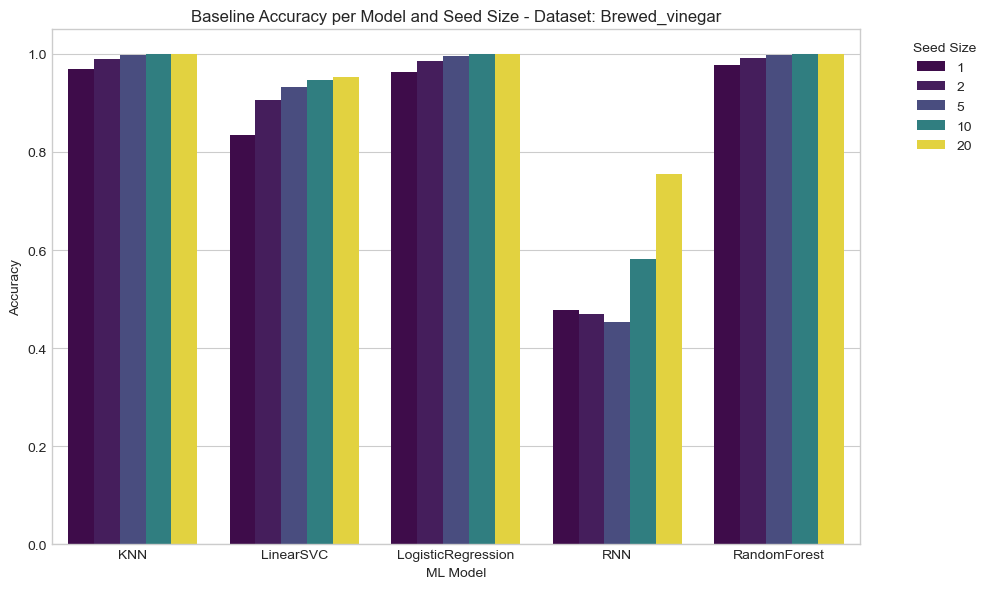

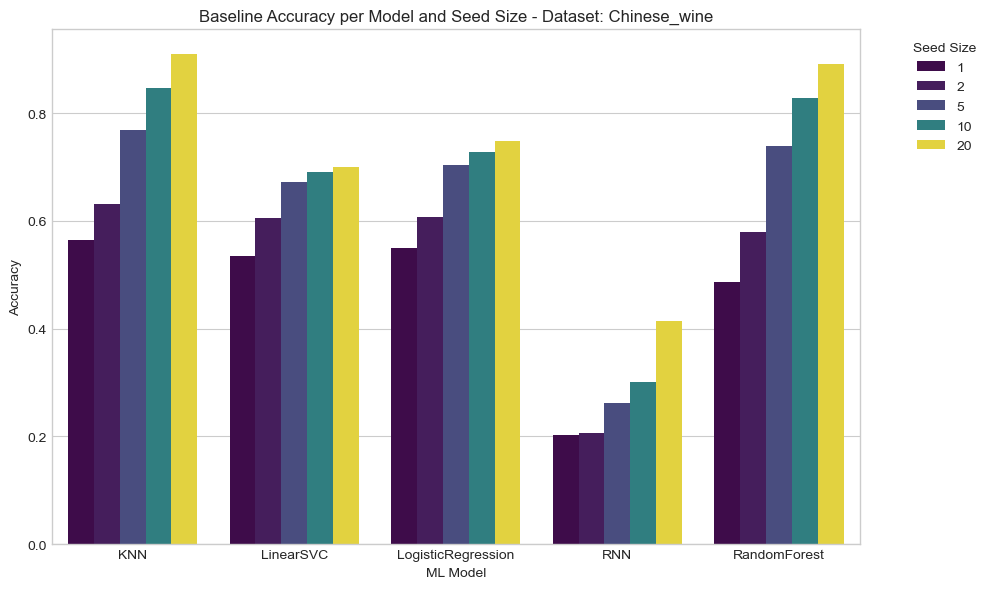

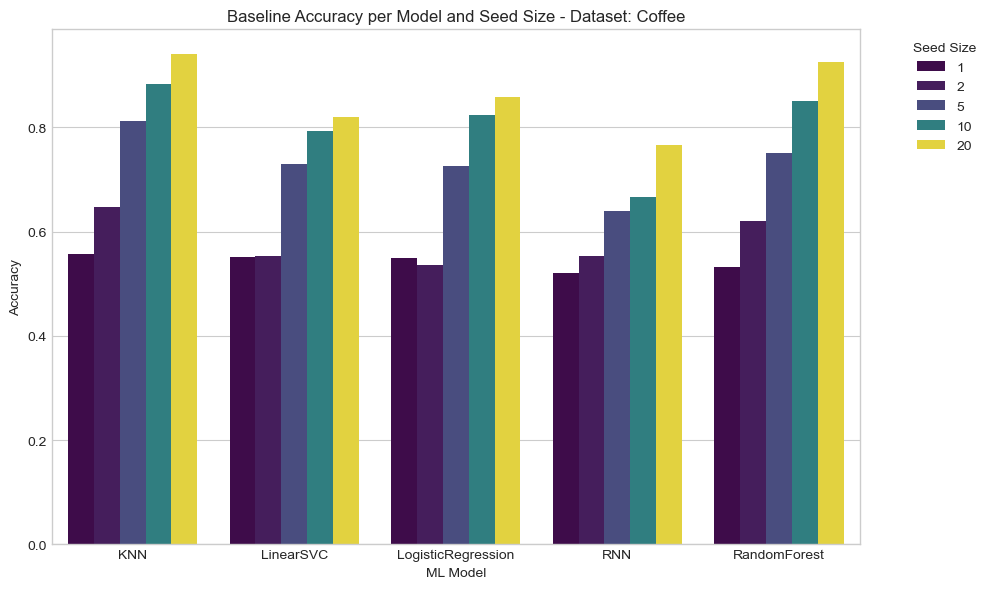

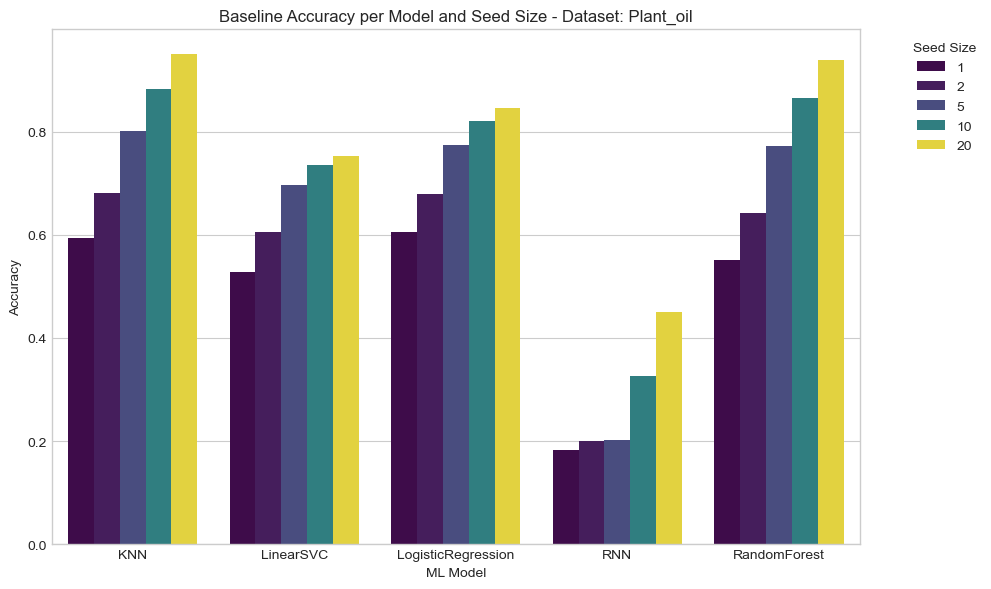

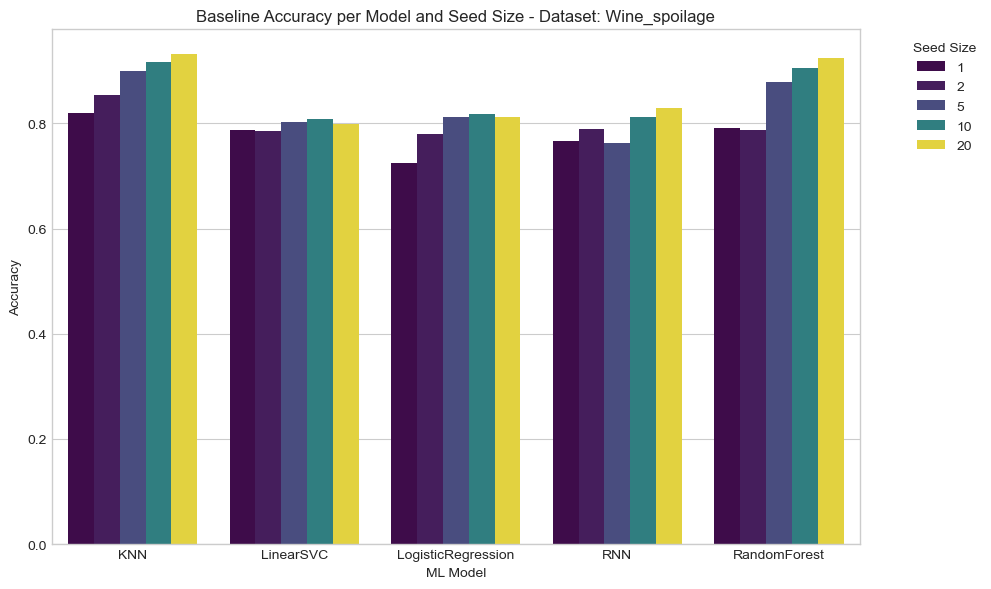

=== Average Baseline Performance Across All 5 Datasets ===


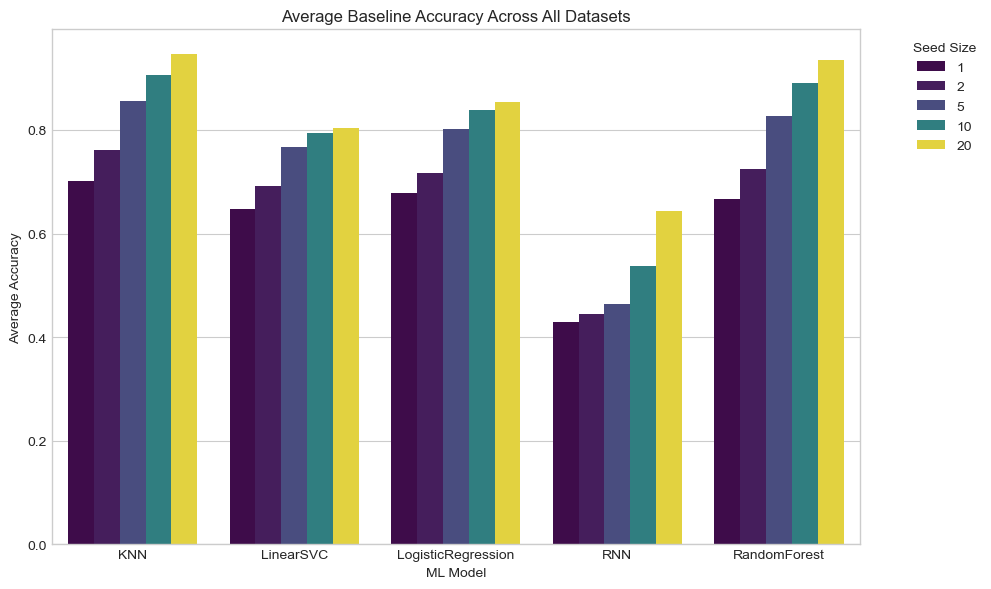

In [9]:
# Extract baseline data and calculate average by Dataset, Model, SeedsPerLabel, Method
df_baseline = df_all[df_all['Method'].isin(['Baseline', 'Tuned_Baseline'])].copy()
baseline_mean = df_baseline.groupby(['Dataset', 'Model', 'SeedsPerLabel', 'Method'])['Accuracy'].mean().reset_index()

# Prioritize Tuned_Baseline, fallback to Baseline if missing
def get_best_baseline(group):
    if 'Tuned_Baseline' in group['Method'].values:
        return group[group['Method'] == 'Tuned_Baseline']
    return group[group['Method'] == 'Baseline']

baseline_agg = baseline_mean.groupby(['Dataset', 'Model', 'SeedsPerLabel']).apply(get_best_baseline).reset_index(drop=True)

datasets = baseline_agg['Dataset'].unique()

print("=== Research question 1: Baseline Performance ===")
for dataset in datasets:
    df_ds = baseline_agg[baseline_agg['Dataset'] == dataset]
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_ds, x='Model', y='Accuracy', hue='SeedsPerLabel', palette='viridis')
    plt.title(f"Baseline Accuracy per Model and Seed Size - Dataset: {dataset}")
    plt.ylabel("Accuracy")
    plt.xlabel("ML Model")
    plt.legend(title='Seed Size', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f'Output_Figures/RQ1_Baseline_{dataset}.png', dpi=300, bbox_inches='tight')
    plt.show()

print("=== Average Baseline Performance Across All 5 Datasets ===")
overall_baseline = baseline_agg.groupby(['Model', 'SeedsPerLabel'])['Accuracy'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=overall_baseline, x='Model', y='Accuracy', hue='SeedsPerLabel', palette='viridis')
plt.title("Average Baseline Accuracy Across All Datasets")
plt.ylabel("Average Accuracy")
plt.xlabel("ML Model")
plt.legend(title='Seed Size', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Output_Figures/RQ1_Baseline_Overall.png', dpi=300, bbox_inches='tight')
plt.show()

## Research question 2: How synthetic data affect each ML algorithm
2 column tables - 1 is ML method, one is Gen method - average all other factors. Showing average of Accuracy Change compared to baseline.

In [10]:
# Create a dataframe containing baseline for each fold to calculate Paired Difference)
df_baseline = df_all[df_all['Method'].isin(['Baseline', 'Tuned_Baseline'])].copy()

def get_best_baseline_per_fold(group):
    if 'Tuned_Baseline' in group['Method'].values:
        return group[group['Method'] == 'Tuned_Baseline']
    return group[group['Method'] == 'Baseline']

baseline_per_fold = df_baseline.groupby(['Dataset', 'Model', 'SeedsPerLabel', 'Fold']).apply(get_best_baseline_per_fold).reset_index(drop=True)
baseline_lookup = baseline_per_fold.rename(columns={'Accuracy': 'Baseline_Accuracy'})[['Dataset', 'Model', 'SeedsPerLabel', 'Fold', 'Baseline_Accuracy']]

# Get the synthetic data generation methods)
df_gen = df_all[~df_all['Method'].isin(['Baseline', 'Tuned_Baseline'])].copy()

# Merge gen data with baseline by (Dataset, Model, SeedsPerLabel, Fold))
df_gen_merged = pd.merge(df_gen, baseline_lookup, on=['Dataset', 'Model', 'SeedsPerLabel', 'Fold'], how='inner')

# Calculate the difference)
df_gen_merged['Accuracy_Change'] = df_gen_merged['Accuracy'] - df_gen_merged['Baseline_Accuracy']

# Pivot table: Model (row) x Gen Method (column), average all other factors x Gen Method, lấy trung bình tất cả các yếu tố khác)
pivot_rq2 = df_gen_merged.pivot_table(index='Model', columns='Method', values='Accuracy_Change', aggfunc='mean')
display(pivot_rq2)


Method,ADASYN,GMM,HMM_GMM,Jittering,Magnitude_Warping,Mixup,SMOTE,Scaling,TimeVAE,Time_Warping
Model,,,,,,,,,,
KNN,0.008072,-0.000114,-0.004356,0.003270,-0.006572,0.005857,0.007070,-0.002682,-0.004626,-0.007548
LinearSVC,0.008204,-0.011363,-0.106998,0.003205,-0.025952,-0.001891,-0.004330,-0.007219,-0.097327,-0.067376
LogisticRegression,-0.007938,-0.014104,-0.088510,0.004712,-0.020924,-0.001649,-0.004776,-0.006997,-0.086460,-0.057629
RNN,0.086498,0.147412,0.049761,0.107136,0.099799,0.150284,0.149352,0.103109,-0.027234,0.093541
RandomForest,-0.001765,-0.003012,-0.005587,0.014637,0.003790,0.001148,0.000815,0.004770,-0.003728,-0.024468


## Data Preparation for Plot 3 and 4
We need to connect the `ScaleFactor=1` (which is the baseline performance) to the generation methods. với các phương pháp sinh dữ liệu.)

In [11]:
df_baseline_start = df_all[df_all['Method'] == 'Tuned_Baseline'].copy()
if df_baseline_start.empty:
    df_baseline_start = df_all[df_all['Method'] == 'Baseline'].copy()
df_baseline_start['ScaleFactor'] = 1

gen_methods = [m for m in df_all['Method'].unique() if m not in ['Baseline', 'Tuned_Baseline']]

df_plot_list = []
for gen_method in gen_methods:
    df_temp = df_baseline_start.copy()
    df_temp['Method'] = gen_method
    df_plot_list.append(df_temp)

df_plot_list.append(df_gen)
df_plot = pd.concat(df_plot_list, ignore_index=True)

df_plot_agg = df_plot.groupby(['Model', 'Method', 'SeedsPerLabel', 'ScaleFactor'])['Accuracy'].mean().reset_index()

## Research question 3: How synthetic data scaling and generation seed size affect results
Average fold/dataset, separate line figure for each ML with n generation seed size. 
X-axis is scaling size (1x to 10x), Y-axis is value, number of lines = number of gen method., Trục Y là giá trị, số đường = số phương pháp sinh dữ liệu.)

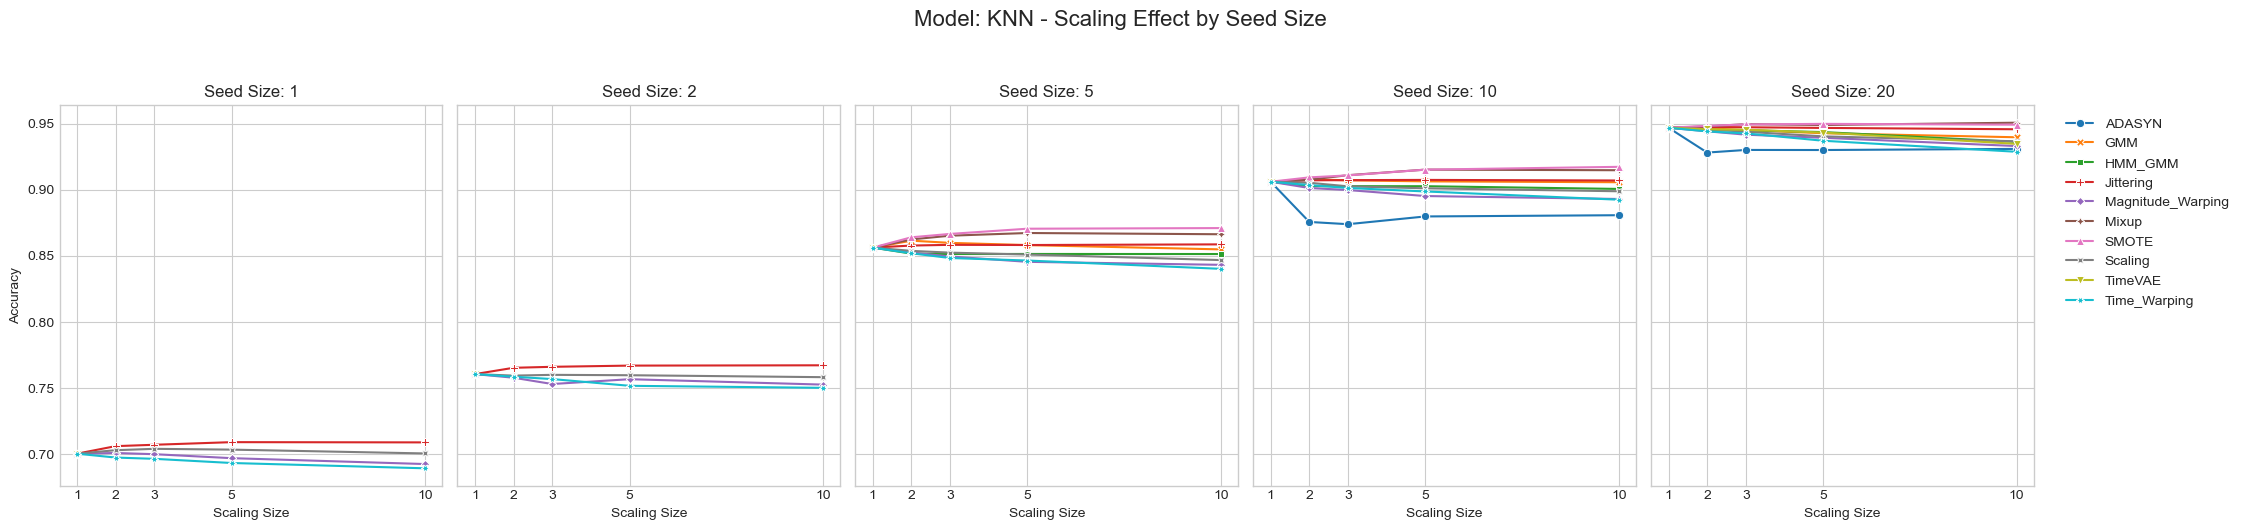

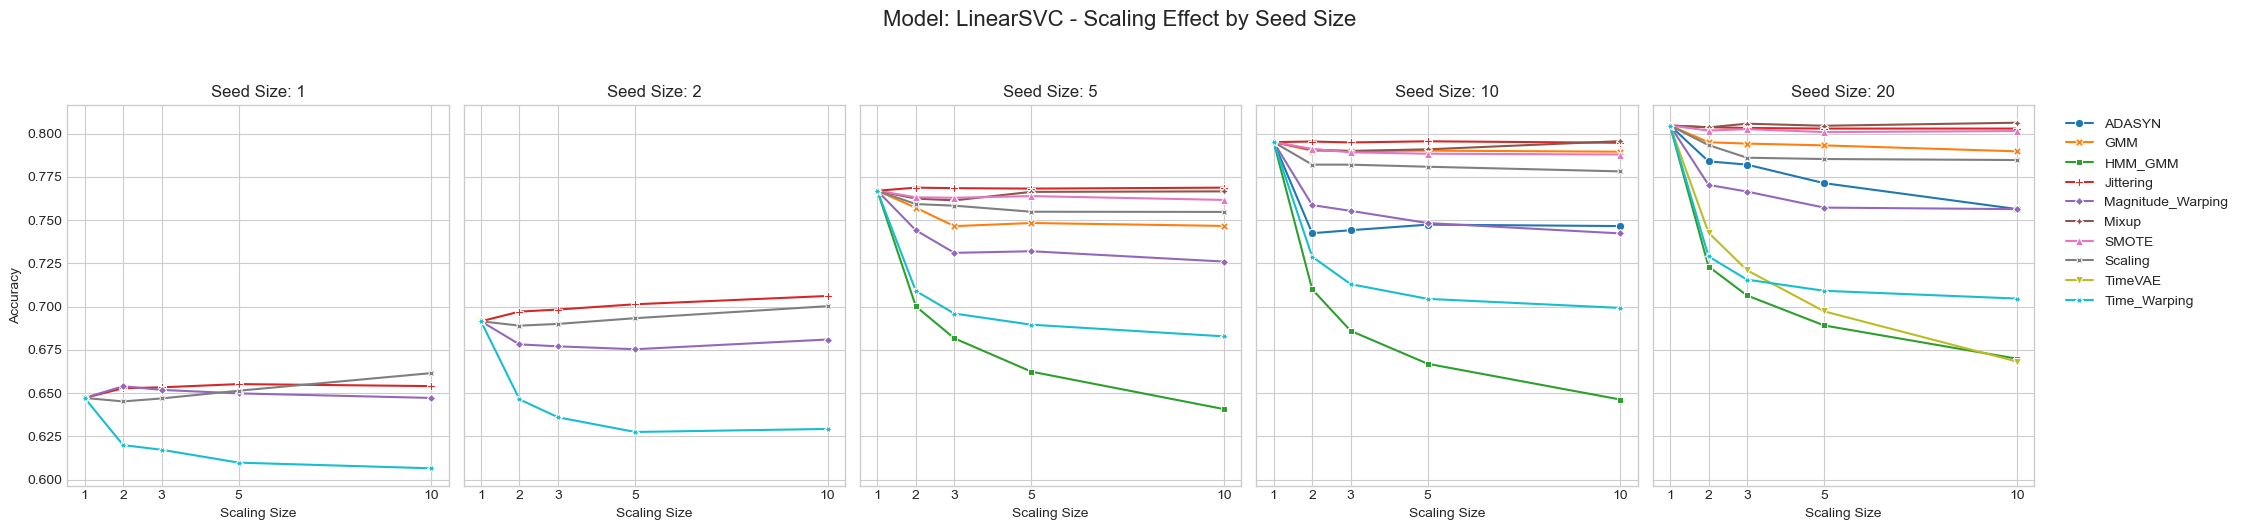

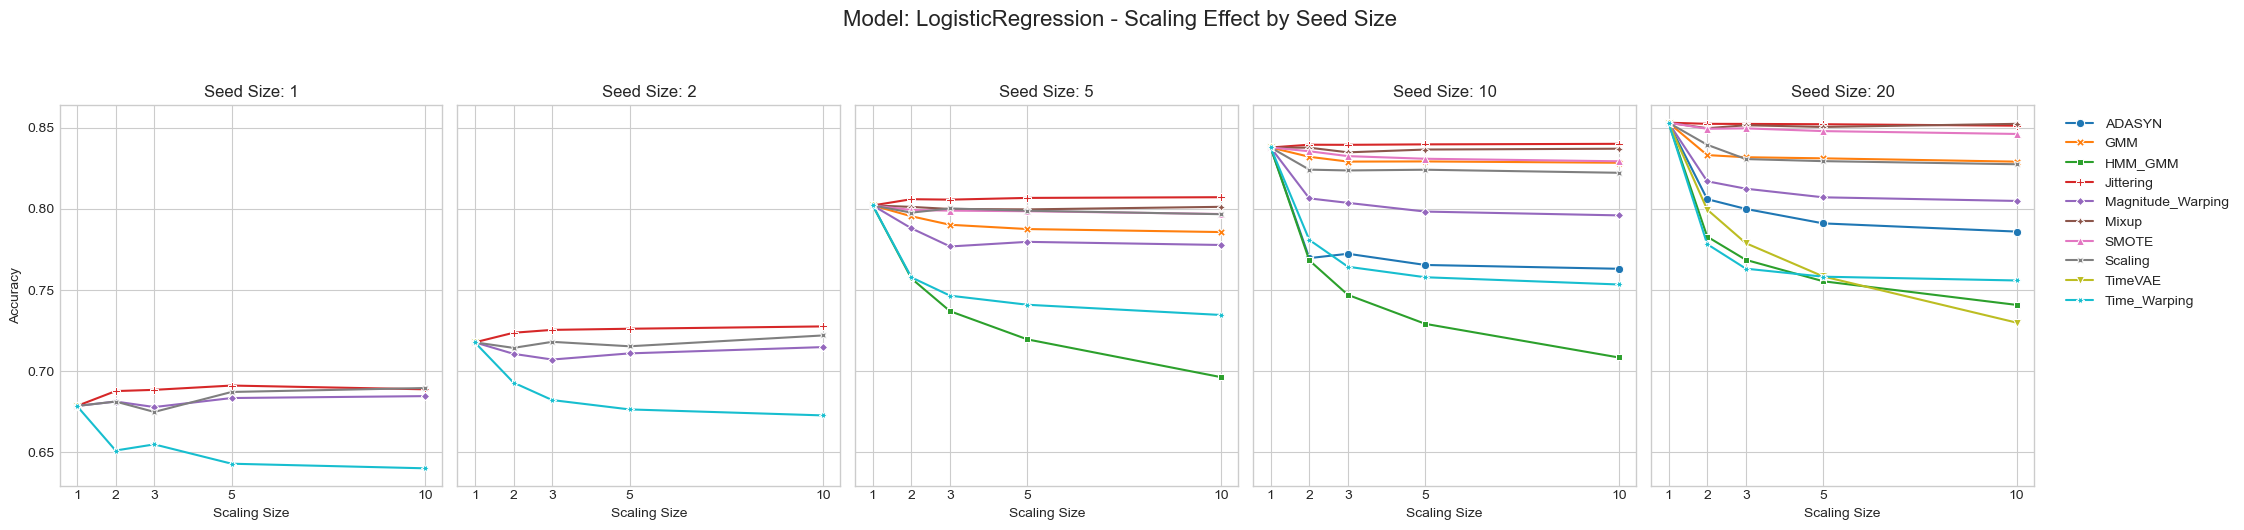

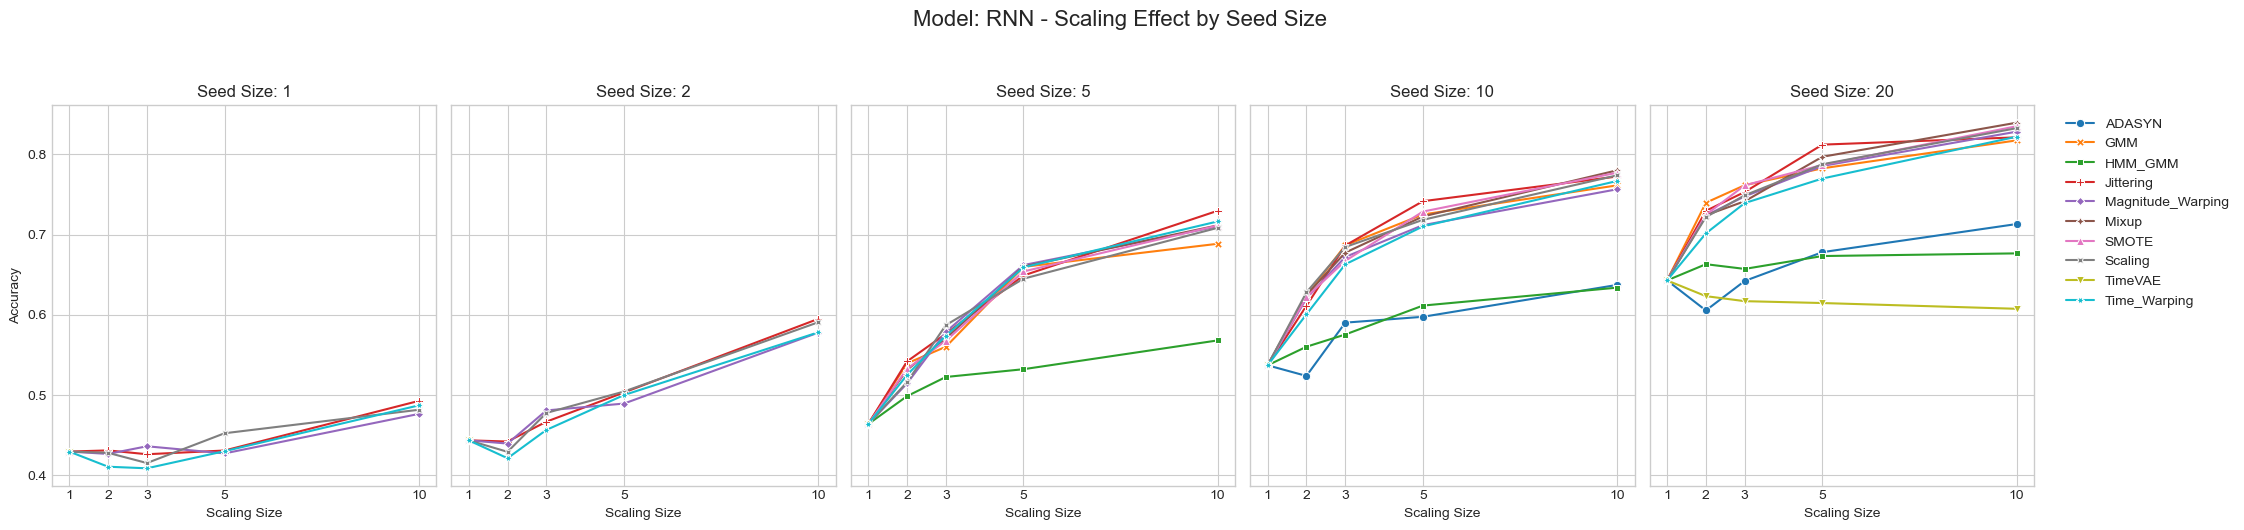

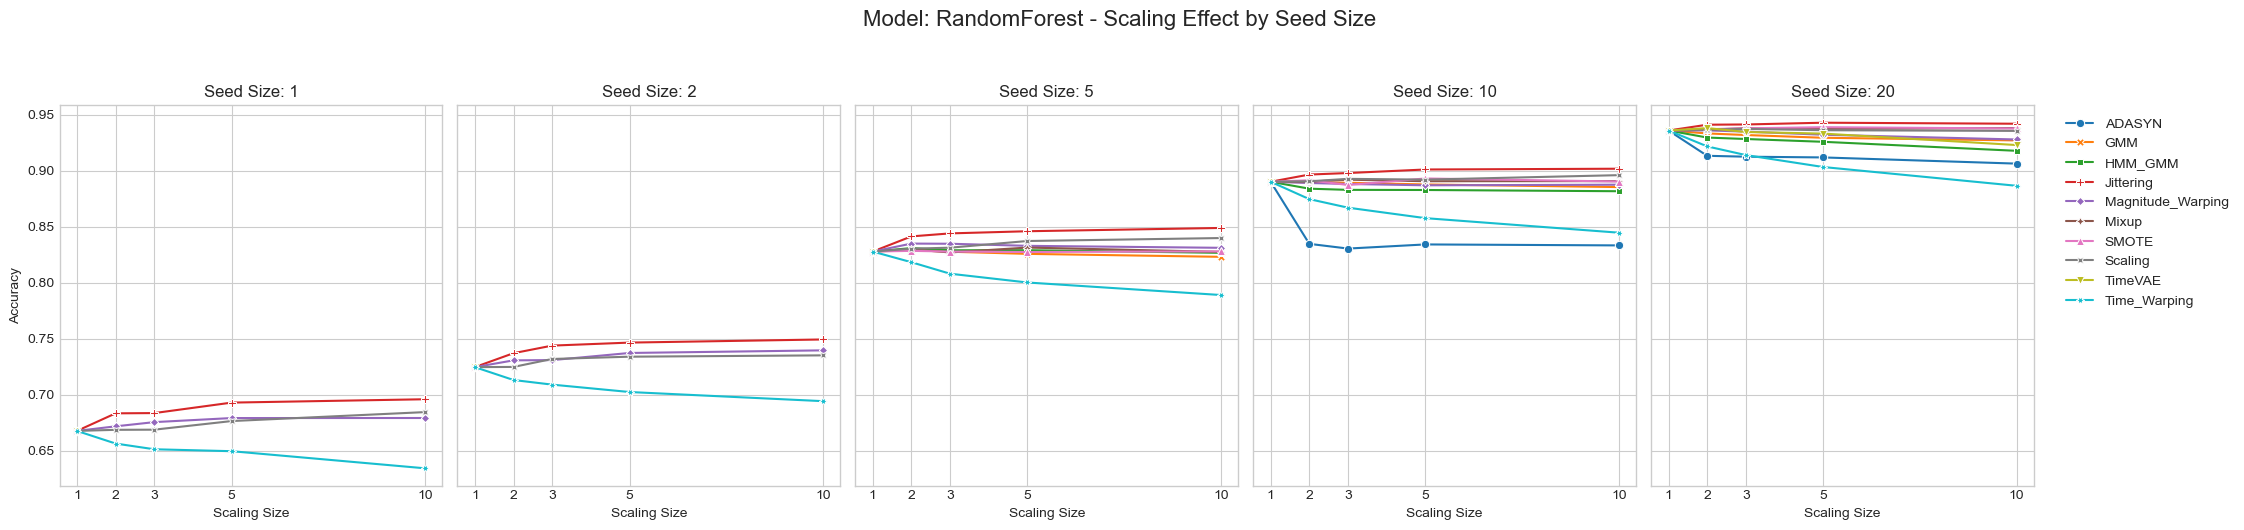

In [12]:
models = df_plot_agg['Model'].unique()
seed_sizes = sorted(df_plot_agg['SeedsPerLabel'].unique())

for model in models:
    df_model = df_plot_agg[df_plot_agg['Model'] == model]
    
    fig, axes = plt.subplots(1, len(seed_sizes), figsize=(4.5 * len(seed_sizes), 5), sharey=True)
    fig.suptitle(f"Model: {model} - Scaling Effect by Seed Size", fontsize=16, y=1.05)
    
    if len(seed_sizes) == 1:
        axes = [axes]
        
    for i, seed in enumerate(seed_sizes):
        df_seed = df_model[df_model['SeedsPerLabel'] == seed]
        ax = axes[i]
        sns.lineplot(data=df_seed, x='ScaleFactor', y='Accuracy', hue='Method', style='Method', markers=True, dashes=False, ax=ax)
        ax.set_title(f"Seed Size: {seed}")
        ax.set_xlabel("Scaling Size")
        if i == 0:
            ax.set_ylabel("Accuracy")
        else:
            ax.set_ylabel("")
        ax.set_xticks([1, 2, 3, 5, 10])
        
        # Only keep legend for the last plot to save space
        if i < len(seed_sizes) - 1:
            if ax.get_legend() is not None:
                ax.get_legend().remove()
        else:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            
    plt.tight_layout()
    plt.savefig(f'Output_Figures/RQ3_{model}_Scaling_SeedSize.png', dpi=300, bbox_inches='tight')
    plt.show()

## Research question 4: Effect of Seed Size for each ML method and Gen method
For each ML method x 5 gen method - put result of all seed size (baseline) with 5 starting point x 5 line. 
X-axis is scaling size (1x to 10x), Y-axis is value., Trục Y là giá trị.)

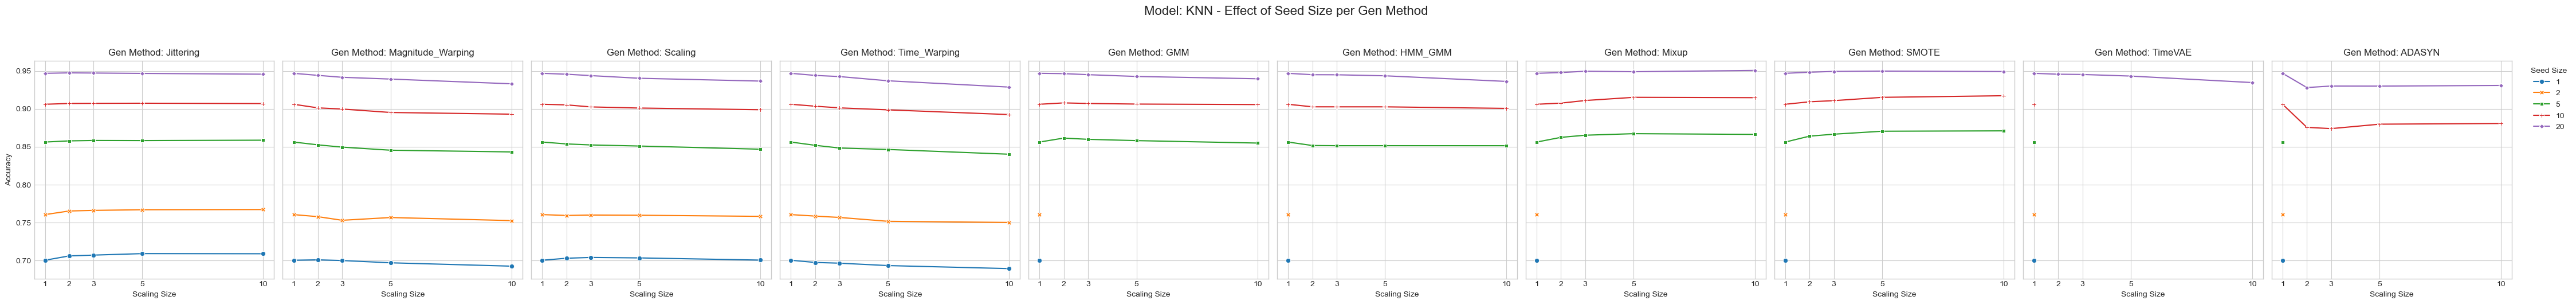

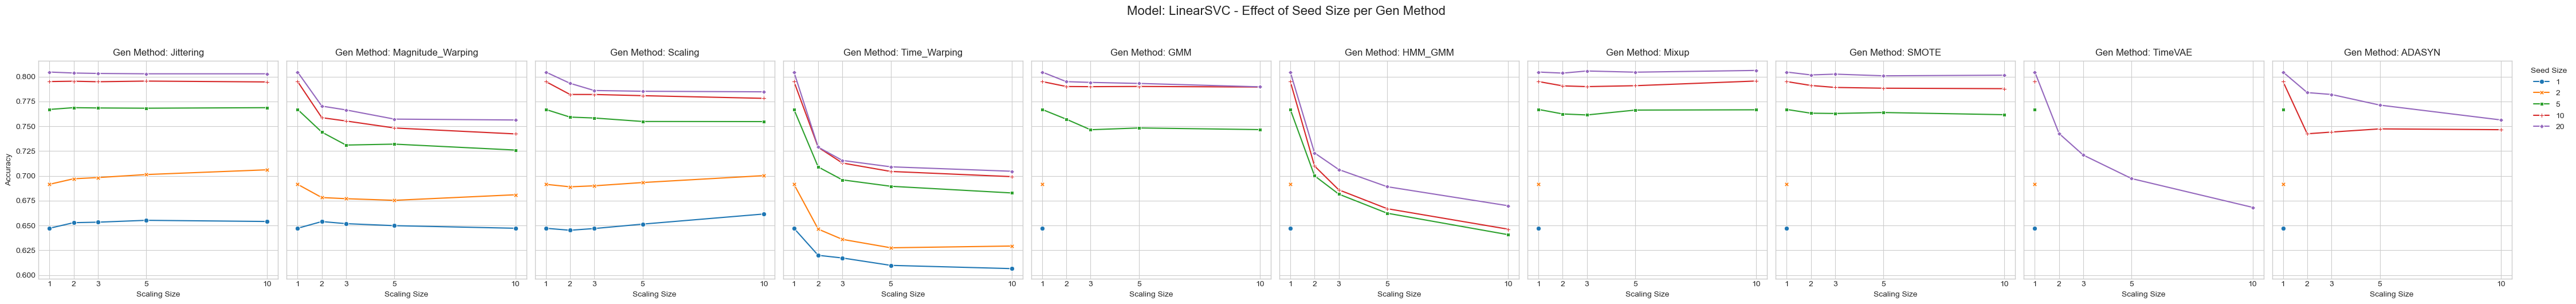

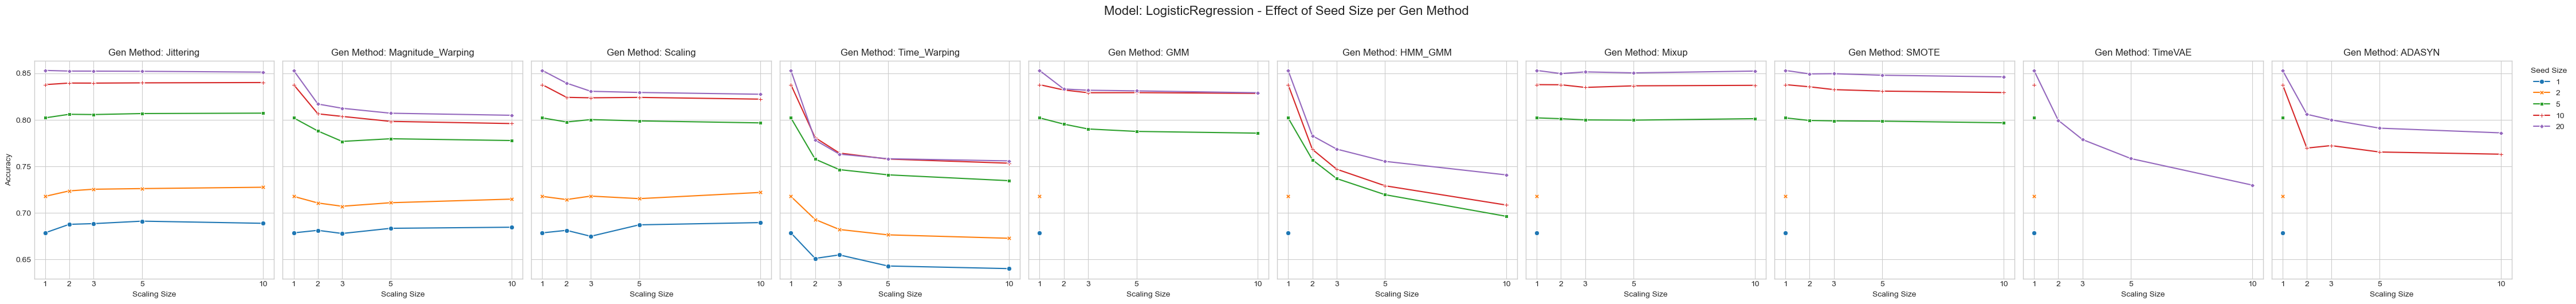

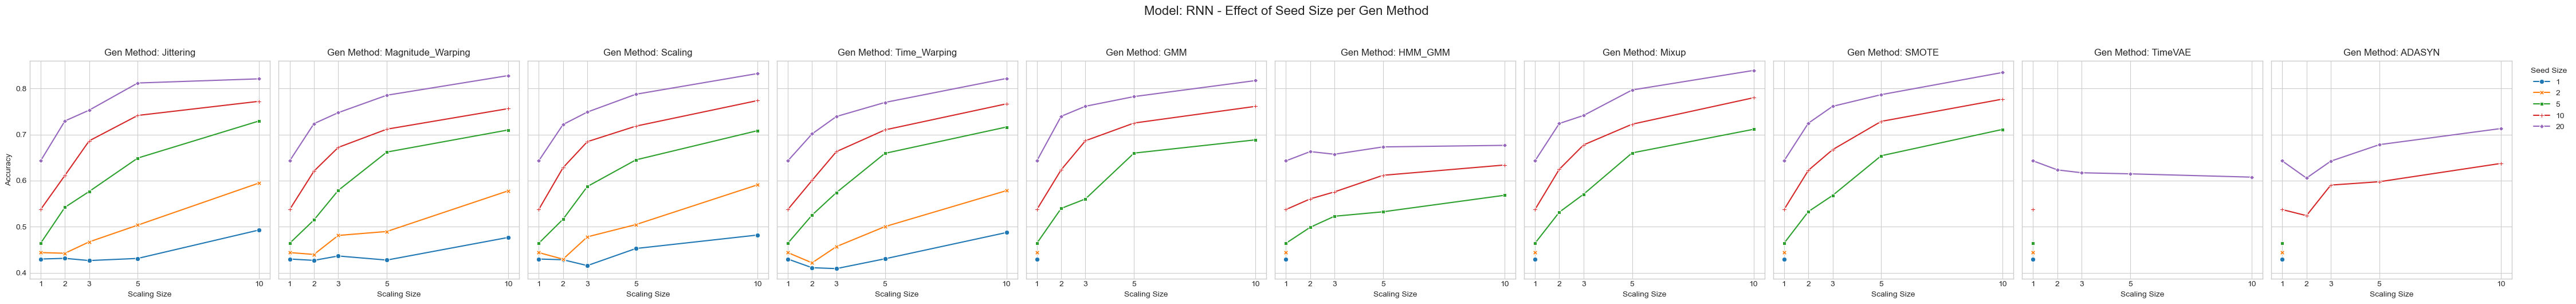

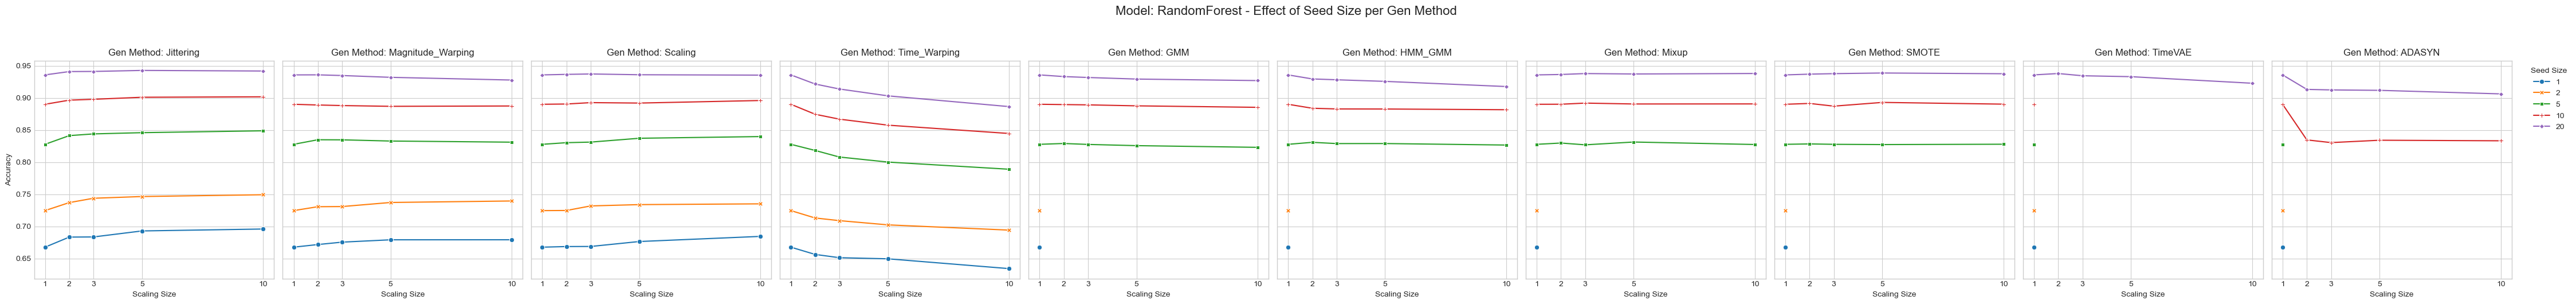

In [13]:
hue_order_rq4 = [str(s) for s in sorted(df_plot_agg['SeedsPerLabel'].unique())]

for model in models:
    df_model = df_plot_agg[df_plot_agg['Model'] == model]
    
    fig, axes = plt.subplots(1, len(gen_methods), figsize=(4.5 * len(gen_methods), 5), sharey=True)
    fig.suptitle(f"Model: {model} - Effect of Seed Size per Gen Method", fontsize=16, y=1.05)
    
    if len(gen_methods) == 1:
        axes = [axes]
        
    for i, gen_method in enumerate(gen_methods):
        df_gen_m = df_model[df_model['Method'] == gen_method].copy()
        df_gen_m['SeedsPerLabel'] = df_gen_m['SeedsPerLabel'].astype(str)
        ax = axes[i]
        
        sns.lineplot(data=df_gen_m, x='ScaleFactor', y='Accuracy', hue='SeedsPerLabel', style='SeedsPerLabel', hue_order=hue_order_rq4, style_order=hue_order_rq4, palette='tab10', markers=True, dashes=False, ax=ax)
        
        ax.set_title(f"Gen Method: {gen_method}")
        ax.set_xlabel("Scaling Size")
        if i == 0:
            ax.set_ylabel("Accuracy")
        else:
            ax.set_ylabel("")
        ax.set_xticks([1, 2, 3, 5, 10])
        
        if i < len(gen_methods) - 1:
            if ax.get_legend() is not None:
                ax.get_legend().remove()
        else:
            ax.legend(title='Seed Size', bbox_to_anchor=(1.05, 1), loc='upper left')
            
    plt.tight_layout()
    plt.savefig(f'Output_Figures/RQ4_{model}_SeedSize_GenMethod.png', dpi=300, bbox_inches='tight')
    plt.show()